In [1]:
!pip install transformers datasets underthesea openpyxl

  Using cached underthesea-9.2.11-py3-none-any.whl.metadata (18 kB)
  Using cached underthesea_core-3.3.0-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (5.7 kB)
Using cached underthesea-9.2.11-py3-none-any.whl (7.0 MB)
Using cached underthesea_core-3.3.0-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (1.5 MB)


In [2]:
import pandas as pd
import torch
import re
from datasets import Dataset
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from transformers import TrainingArguments, Trainer
from sklearn.metrics import accuracy_score, precision_recall_fscore_support
from underthesea import word_tokenize

In [3]:
from google.colab import files
uploaded = files.upload()

Saving test.xlsx to test.xlsx
Saving train.xlsx to train.xlsx
Saving val.xlsx to val.xlsx


In [4]:
# LOAD DATA
train_df = pd.read_excel("train.xlsx")
val_df = pd.read_excel("val.xlsx")
test_df = pd.read_excel("test.xlsx")

train_df = train_df.rename(columns={"cmt_col":"text","labels":"label"})
val_df = val_df.rename(columns={"cmt_col":"text","labels":"label"})
test_df = test_df.rename(columns={"cmt_col":"text","labels":"label"})

In [5]:
# STOPWORDS
vietnamese_stopwords = set([
    "là","và","của","thì","những","các","tại","bị","bởi","với",
    "để","như","này","đó","kia","trong","trên","dưới","cho",
    "về","khi","có","không","gì","nào","đâu","rồi","lại"
])

In [6]:
# CLEAN TEXT
def clean_text(text):
    text = str(text).lower()

    # Xóa URL
    text = re.sub(r'http\S+', '', text)

    # Xóa ký tự đặc biệt
    text = re.sub(r'[^\w\s]', ' ', text)

    # Xóa khoảng trắng thừa
    text = re.sub(r'\s+', ' ', text).strip()

    # Xóa stopwords
    words = text.split()
    words = [w for w in words if w not in vietnamese_stopwords]

    return " ".join(words)

In [7]:
# TOKENIZE TIẾNG VIỆT
def vietnamese_tokenize(text):
    if not text:
        return ""
    return word_tokenize(text, format="text")

# ÁP DỤNG TIỀN XỬ LÝ
def preprocess(df):
    df["text"] = df["text"].apply(clean_text)
    df["text"] = df["text"].apply(vietnamese_tokenize)
    return df

In [8]:
train_df = train_df.rename(columns={"content":"text"})
val_df = val_df.rename(columns={"content":"text"})
test_df = test_df.rename(columns={"content":"text"})
train_df = preprocess(train_df)
val_df = preprocess(val_df)
test_df = preprocess(test_df)

In [9]:
# CHUYỂN SANG DATASET HF
train_dataset = Dataset.from_pandas(train_df)
val_dataset = Dataset.from_pandas(val_df)
test_dataset = Dataset.from_pandas(test_df)

In [10]:
# TOKENIZER PHOBERT
tokenizer = AutoTokenizer.from_pretrained("vinai/phobert-base")

def tokenize_function(example):
    return tokenizer(
        example["text"],   # đúng cột text
        padding="max_length",
        truncation=True,
        max_length=128
    )

train_dataset = train_dataset.map(tokenize_function, batched=True)
val_dataset = val_dataset.map(tokenize_function, batched=True)
test_dataset = test_dataset.map(tokenize_function, batched=True)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/557 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

bpe.codes: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Map:   0%|          | 0/6267 [00:00<?, ? examples/s]

Map:   0%|          | 0/1343 [00:00<?, ? examples/s]

Map:   0%|          | 0/1343 [00:00<?, ? examples/s]

In [11]:
# FORMAT TORCH
train_dataset.set_format(type="torch", columns=["input_ids","attention_mask","label"])
val_dataset.set_format(type="torch", columns=["input_ids","attention_mask","label"])
test_dataset.set_format(type="torch", columns=["input_ids","attention_mask","label"])

In [12]:
# MODEL PHOBERT
model = AutoModelForSequenceClassification.from_pretrained(
    "vinai/phobert-base",
    num_labels=3
)

pytorch_model.bin:   0%|          | 0.00/543M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/543M [00:00<?, ?B/s]

RobertaForSequenceClassification LOAD REPORT from: vinai/phobert-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.decoder.bias            | UNEXPECTED | 
roberta.pooler.dense.weight     | UNEXPECTED | 
lm_head.decoder.weight          | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
roberta.pooler.dense.bias       | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
classifier.out_proj.weight      | MISSING    | 
classifier.dense.weight         | MISSING    | 
classifier.dense.bias           | MISSING    | 
classifier.out_proj.bias        | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initia

In [13]:
# METRICS
def compute_metrics(pred):
    labels = pred.label_ids
    preds = pred.predictions.argmax(-1)

    precision, recall, f1, _ = precision_recall_fscore_support(labels, preds, average="weighted")
    acc = accuracy_score(labels, preds)

    return {
        "accuracy": acc,
        "f1": f1,
        "precision": precision,
        "recall": recall
    }

In [14]:
# TRAINING ARGUMENTS
training_args = TrainingArguments(
    output_dir="./results",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=3,
    weight_decay=0.01,
    eval_strategy="epoch", # Changed from evaluation_strategy
    save_strategy="epoch",
    logging_dir="./logs"
)

`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


In [15]:
# TRAINER
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    compute_metrics=compute_metrics
)

# TRAIN
trainer.train()

# TEST
trainer.evaluate(test_dataset)

Epoch,Training Loss,Validation Loss,Accuracy,F1,Precision,Recall
1,No log,0.259767,0.910648,0.910919,0.911735,0.910648
2,0.486088,0.244184,0.926284,0.926147,0.926244,0.926284
3,0.197374,0.259698,0.922561,0.922441,0.922484,0.922561


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

{'eval_loss': 0.26619258522987366,
 'eval_accuracy': 0.9225614296351452,
 'eval_f1': 0.9224229611836531,
 'eval_precision': 0.922644163815673,
 'eval_recall': 0.9225614296351452,
 'eval_runtime': 9.8777,
 'eval_samples_per_second': 135.963,
 'eval_steps_per_second': 8.504,
 'epoch': 3.0}

In [16]:
import pandas as pd

# Combine labels from all datasets
all_labels = pd.concat([train_df['label'], val_df['label'], test_df['label']])

# Calculate label distribution
label_distribution = all_labels.value_counts().sort_index()

# Define label mapping
label_mapping = {
    0: "Clean",
    1: "Offensive",
    2: "Hate/harassment"
}

# Map numerical labels to descriptive names
mapped_distribution = label_distribution.rename(index=label_mapping)

print("Distribution of labels in the overall dataset:")
print(mapped_distribution)

# Optional: Display percentage distribution
print("\nPercentage Distribution:")
print(mapped_distribution / mapped_distribution.sum() * 100)

Distribution of labels in the overall dataset:
label
Clean              3200
Offensive          2753
Hate/harassment    3000
Name: count, dtype: int64

Percentage Distribution:
label
Clean              35.742209
Offensive          30.749469
Hate/harassment    33.508321
Name: count, dtype: float64


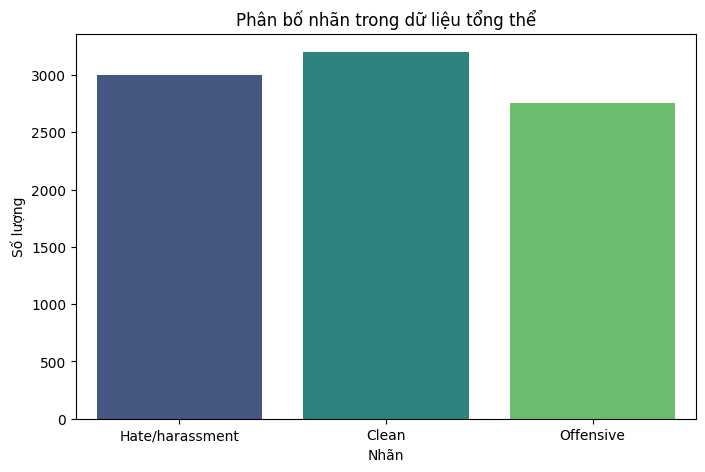

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
import pandas as pd

# Map numerical labels to descriptive names for plotting
label_map = {0: 'Clean', 1: 'Offensive', 2: 'Hate/harassment'}

# Ensure combined_df and toxic_comments_df are used correctly
# combined_df should contain all data (train, val, test)
# toxic_comments_df contains comments with labels 1 or 2

# If combined_df or toxic_comments_df are not already in your kernel, you'd need to recreate them here.
# Based on the kernel state, they are available.

# Adding a 'label_name' column to combined_df for better plot readability
combined_df['label_name'] = combined_df['label'].map(label_map)

# 1. Phân bố nhãn (Label Distribution)
plt.figure(figsize=(8, 5))
sns.countplot(x='label_name', data=combined_df, hue='label_name', palette='viridis', legend=False)
plt.title('Phân bố nhãn trong dữ liệu tổng thể')
plt.xlabel('Nhãn')
plt.ylabel('Số lượng')
plt.show()


In [25]:
# 1. LƯU MODEL
#model.save_pretrained("./toxic_model")
#tokenizer.save_pretrained("./toxic_model")

# 2. XEM KẾT QUẢ CHI TIẾT TRÊN TEST SET
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np

# Predict trên test set
predictions = trainer.predict(test_dataset)
preds = np.argmax(predictions.predictions, axis=-1)
labels = predictions.label_ids

# Classification report
print("Classification Report:")
print(classification_report(labels, preds, target_names=["Clean", "Offensive", "Hate"]))

# Confusion matrix
print("\nConfusion Matrix:")
print(confusion_matrix(labels, preds))

# 3. THỬ PREDICT VỚI CÂU MỚI
def predict_text(text):
    # Tiền xử lý
    text = clean_text(text)
    text = vietnamese_tokenize(text)

    # Tokenize
    inputs = tokenizer(text, return_tensors="pt", padding=True, truncation=True, max_length=128)

    # Move inputs to the same device as the model
    inputs = {k: v.to(model.device) for k, v in inputs.items()}

    # Predict
    with torch.no_grad():
        outputs = model(**inputs)
        pred = torch.argmax(outputs.logits, dim=-1).item()

    labels = {0: "Clean", 1: "Offensive", 2: "Hate/harassment"}
    return labels[pred]


Classification Report:
              precision    recall  f1-score   support

       Clean       0.93      0.91      0.92       480
   Offensive       0.92      0.96      0.94       413
        Hate       0.91      0.90      0.91       450

    accuracy                           0.92      1343
   macro avg       0.92      0.92      0.92      1343
weighted avg       0.92      0.92      0.92      1343


Confusion Matrix:
[[437  13  30]
 [  8 396   9]
 [ 23  21 406]]


In [30]:
# ====== TEST MODEL TRÊN TẬP TEST ======

from sklearn.metrics import classification_report, confusion_matrix
import numpy as np

# Predict trên test set
predictions = trainer.predict(test_dataset)
preds = np.argmax(predictions.predictions, axis=-1)
labels = predictions.label_ids

# Mapping label
LABEL_MAP = {0: "Clean", 1: "Offensive", 2: "Hate"}

# ====== 1. CLASSIFICATION REPORT ======
print("=" * 60)
print("CLASSIFICATION REPORT")
print("=" * 60)
print(classification_report(labels, preds, target_names=["Clean", "Offensive", "Hate"]))

# ====== 2. CONFUSION MATRIX ======
print("\nCONFUSION MATRIX:")
print(confusion_matrix(labels, preds))

# ====== 3. XEM CHI TIẾT MỘT SỐ MẪU ======
print("\n" + "=" * 60)
print("CHI TIẾT 20 MẪU ĐẦU TIÊN TRONG TẬP TEST")
print("=" * 60)

for i in range(min(20, len(test_df))):
    text = test_df.iloc[i]['text']
    true_label = labels[i]
    pred_label = preds[i]

    status = "✅" if true_label == pred_label else "❌"

    print(f"{status} [{LABEL_MAP[pred_label]}] | True: {LABEL_MAP[true_label]} | {text[:60]}...")

# ====== 4. THỐNG KÊ ======
correct = (preds == labels).sum()
total = len(labels)
print("\n" + "=" * 60)
print("THỐNG KÊ")
print("=" * 60)
print(f"Tổng số mẫu test: {total}")
print(f"Dự đoán đúng: {correct} ({correct/total*100:.2f}%)")
print(f"Dự đoán sai: {total - correct} ({(total-correct)/total*100:.2f}%)")

# ====== 5. TEST VỚI CÂU TỰ NHẬP ======
def predict_single(text):
    # Tiền xử lý
    cleaned = clean_text(text)
    tokenized = vietnamese_tokenize(cleaned)

    # Tokenize
    inputs = tokenizer(tokenized, return_tensors="pt", padding=True, truncation=True, max_length=128)
    inputs = {k: v.to(model.device) for k, v in inputs.items()}

    # Predict
    with torch.no_grad():
        outputs = model(**inputs)
        probs = torch.softmax(outputs.logits, dim=-1)
        pred_label = torch.argmax(probs, dim=-1).item()
        confidence = probs[0][pred_label].item()

    return LABEL_MAP[pred_label], confidence

# Test thử vài câu
print("\n" + "=" * 60)
print("TEST VỚI CÂU MẪU")
print("=" * 60)

test_samples = [
    "Shop giao hàng nhanh quá, cảm ơn nhé",
    "mày lừa đảo à",
    "thằng bắc kỳ chỉ biết lừa đảo",
    "Sản phẩm tốt, đóng gói cẩn thận",
    "đm shop lừa đảo",
    "ngu quá trời ngu"
]

for text in test_samples:
    label, conf = predict_single(text)
    print(f"[{label}] ({conf:.2%}) | {text}")

CLASSIFICATION REPORT
              precision    recall  f1-score   support

       Clean       0.93      0.91      0.92       480
   Offensive       0.92      0.96      0.94       413
        Hate       0.91      0.90      0.91       450

    accuracy                           0.92      1343
   macro avg       0.92      0.92      0.92      1343
weighted avg       0.92      0.92      0.92      1343


CONFUSION MATRIX:
[[437  13  30]
 [  8 396   9]
 [ 23  21 406]]

CHI TIẾT 20 MẪU ĐẦU TIÊN TRONG TẬP TEST
❌ [Clean] | True: Hate | đoạn sau 16 00 ca chào anh_chị chung tôi nhận được đơn tố_gi...
✅ [Hate] | True: Hate | thằng can đúng khôn_khôn hơn cả úc sinh_viên làm full time v...
✅ [Clean] | True: Clean | nguồn cấm tìm nguồn thay_thế thôi...
✅ [Hate] | True: Hate | thằng rủ làm_ăn chung thi_công nội_thất nó luôn nắm nguồn ti...
✅ [Clean] | True: Clean | chào bác em vừa_mới chuyển zalo sang điện_thoại mới mẹ em mà...
✅ [Clean] | True: Clean | bào mòn nhưng ra tiền thanh_xuân tiền hơn bank.

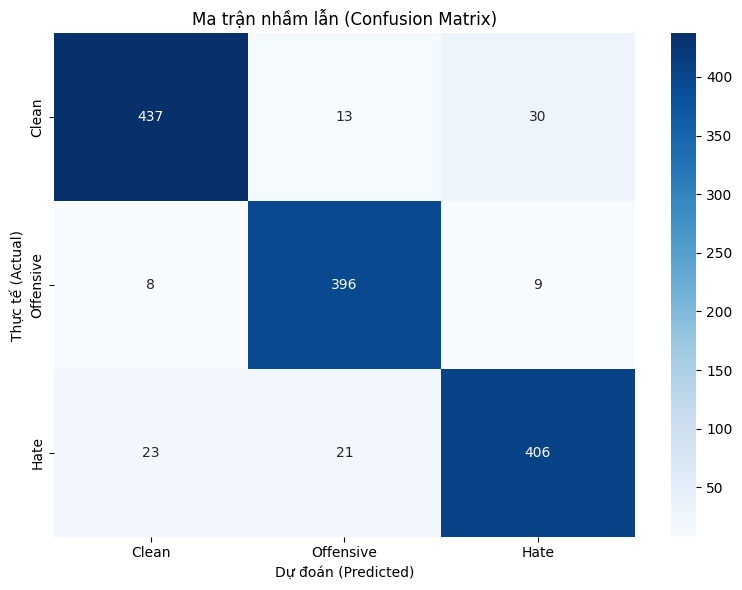

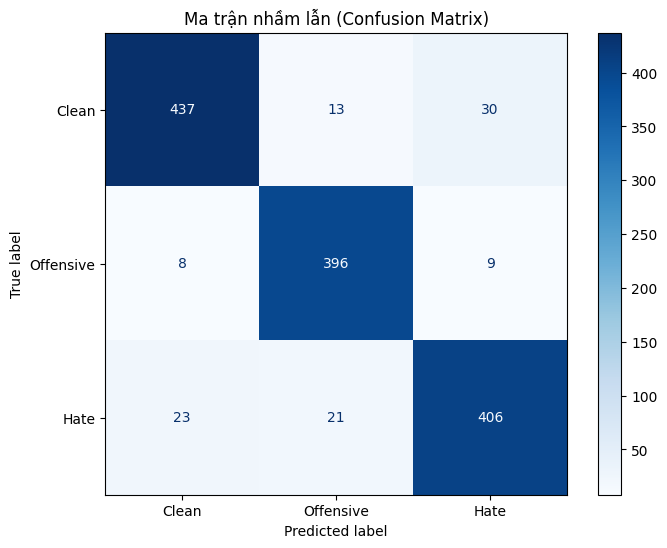


Tổng số mẫu test: 1343
Accuracy: 92.26%


In [31]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import numpy as np

# Predict trên test set
predictions = trainer.predict(test_dataset)
preds = np.argmax(predictions.predictions, axis=-1)
labels = predictions.label_ids

# Tính confusion matrix
cm = confusion_matrix(labels, preds)

# Vẽ confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Clean', 'Offensive', 'Hate'],
            yticklabels=['Clean', 'Offensive', 'Hate'])
plt.xlabel('Dự đoán (Predicted)')
plt.ylabel('Thực tế (Actual)')
plt.title('Ma trận nhầm lẫn (Confusion Matrix)')
plt.tight_layout()
plt.show()

# Hoặc dùng ConfusionMatrixDisplay (đơn giản hơn)
fig, ax = plt.subplots(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                               display_labels=['Clean', 'Offensive', 'Hate'])
disp.plot(cmap='Blues', ax=ax, values_format='d')
plt.title('Ma trận nhầm lẫn (Confusion Matrix)')
plt.grid(False)
plt.show()

# In thêm thống kê
print(f"\nTổng số mẫu test: {len(labels)}")
print(f"Accuracy: {(preds == labels).sum() / len(labels) * 100:.2f}%")

In [29]:
# Test với 20 câu mẫu
test_sentences = [
    # Clean comments
    "Shop giao hàng nhanh quá, cảm ơn nhé",
    "Sản phẩm đẹp lắm, đúng như mô tả",
    "Hàng giao hơi chậm xíu nhưng chất lượng ổn",
    "Đóng gói cẩn thận, shop nhiệt tình",
    "Lần sau mình sẽ ủng hộ tiếp",
    "Giá hơi cao nhưng chất lượng tốt",
    "Giao hàng nhanh, sản phẩm ok",

    # Offensive comments
    "Sản phẩm như cái quần què, phí tiền",
    "mày lừa đảo à",
    "ngu quá trời ngu",
    "đồ rác rưởi, không bao giờ mua nữa",
    "xin link với ông ơi",
    "thằng này bán hàng fake",
    "đm shop lừa đảo",

    # Hate/harassment comments
    "thằng bắc kỳ chỉ biết lừa đảo",
    "mày là đồ chó, cút đi",
    "địt mẹ mày, bán hàng rác",
    "con điên này nói gì vậy",
    "đồ khùng, não có vấn đề à",
    "chửi mày chết mẹ mày luôn"
]

# Mapping label
LABEL_MAP = {
    0: "CLEAN",
    1: "OFFENSIVE",
    2: "HATE"
}

MESSAGE_MAP = {
    0: "✅ Nội dung hợp lệ",
    1: "⚠️ Ngôn ngữ xúc phạm",
    2: "❌ Phát ngôn thù địch"
}

def test_model(sentences):
    results = []

    for text in sentences:
        # Tiền xử lý
        cleaned = clean_text(text)
        tokenized = vietnamese_tokenize(cleaned)

        # Tokenize cho model
        inputs = tokenizer(tokenized, return_tensors="pt", padding=True, truncation=True, max_length=128)

        # Di chuyển sang device của model
        inputs = {k: v.to(model.device) for k, v in inputs.items()}

        # Predict
        with torch.no_grad():
            outputs = model(**inputs)
            probs = torch.softmax(outputs.logits, dim=-1)
            pred_label = torch.argmax(probs, dim=-1).item()
            confidence = probs[0][pred_label].item()

        # Lấy label và message tương ứng
        label = LABEL_MAP[pred_label]
        message = MESSAGE_MAP[pred_label]

        result = f"[{label}] Score: {confidence:.3f} | {text} | {message}"
        results.append(result)
        print(result)

    return results

# Chạy test
print("=" * 80)
print("KẾT QUẢ KIỂM TRA 20 CÂU MẪU")
print("=" * 80)
test_model(test_sentences)

# Thống kê
print("\n" + "=" * 80)
print("THỐNG KÊ")
print("=" * 80)
print(f"Tổng số câu test: {len(test_sentences)}")

KẾT QUẢ KIỂM TRA 20 CÂU MẪU
[CLEAN] Score: 0.995 | Shop giao hàng nhanh quá, cảm ơn nhé | ✅ Nội dung hợp lệ
[CLEAN] Score: 0.994 | Sản phẩm đẹp lắm, đúng như mô tả | ✅ Nội dung hợp lệ
[CLEAN] Score: 0.993 | Hàng giao hơi chậm xíu nhưng chất lượng ổn | ✅ Nội dung hợp lệ
[CLEAN] Score: 0.994 | Đóng gói cẩn thận, shop nhiệt tình | ✅ Nội dung hợp lệ
[CLEAN] Score: 0.994 | Lần sau mình sẽ ủng hộ tiếp | ✅ Nội dung hợp lệ
[CLEAN] Score: 0.990 | Giá hơi cao nhưng chất lượng tốt | ✅ Nội dung hợp lệ
[CLEAN] Score: 0.992 | Giao hàng nhanh, sản phẩm ok | ✅ Nội dung hợp lệ
[CLEAN] Score: 0.892 | Sản phẩm như cái quần què, phí tiền | ✅ Nội dung hợp lệ
[HATE] Score: 0.990 | mày lừa đảo à | ❌ Phát ngôn thù địch
[HATE] Score: 0.920 | ngu quá trời ngu | ❌ Phát ngôn thù địch
[HATE] Score: 0.994 | đồ rác rưởi, không bao giờ mua nữa | ❌ Phát ngôn thù địch
[CLEAN] Score: 0.994 | xin link với ông ơi | ✅ Nội dung hợp lệ
[HATE] Score: 0.994 | thằng này bán hàng fake | ❌ Phát ngôn thù địch
[OFFENSIVE] Score: 0.

In [33]:
# ====== LƯU MODEL VÀ TẢI VỀ MÁY TỪ COLAB ======

from google.colab import files
import shutil
import os

# 1. Lưu model
model.save_pretrained("./phobert_toxic_model")
tokenizer.save_pretrained("./phobert_toxic_model")
print("✅ Đã lưu model vào thư mục ./phobert_toxic_model")

# 2. Nén thành file zip
shutil.make_archive("phobert_toxic_model", 'zip', "./phobert_toxic_model")
print("✅ Đã nén thành file phobert_toxic_model.zip")

# 3. Tải về máy
files.download("phobert_toxic_model.zip")
print("✅ Đang tải về máy...")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

✅ Đã lưu model vào thư mục ./phobert_toxic_model
✅ Đã nén thành file phobert_toxic_model.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ Đang tải về máy...
